# **IV) Google Trends Data Analysis**

1. [**Environment & Setup**](#1-environment--setup)
2. [**Core Functions**](#2-core-functions)
3. [**Data Acquisition Loop**](#3-data-acquisition-loop)
4. [**Trend Visualization**](#4-trend-visualization)

### **1) Environment & Setup** <a id="1-environment--setup"></a>


In [1]:
# pip install pytrends
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pytrends.request import TrendReq

Since Google Trends restricts timeframes, we use a rolling window and combining method.

Scaling artifact:
- Google Trends values are always normalized within the requested time window (0–100).
- When you fetch 2018–2019 and 2020–2021 separately, each block gets its own 0–100 scale.
- When you paste them together: a week that is “2” in 2022–2023 could still represent non-trivial search volume, but it is 2 relative to the peak inside that specific 2-year window.

The minimum fix:

- You must include overlap between windows and use it to rescale the next window onto the previous window's scale. 
- uses 2-year windows with 6-month overlap, 
- rescales each new chunk using the median ratio on the overlap (robust), produces one consistent weekly series.

### **2) Core Functions** <a id="2-core-functions"></a>

1. `fetch()`: Handles API requests with a retry logic and sleep timers to avoid `429 (Too Many Requests)` errors.
2. `stitch()`: Aligns overlapping data points using a median scaling factor.

In [2]:
# 2-year windows with 6-month overlap
WINDOWS = [
    ("2014-01-01","2015-12-31"),
    ("2015-07-01","2017-06-30"),
    ("2017-01-01","2018-12-31"),
    ("2018-07-01","2020-06-30"),
    ("2020-01-01","2021-12-31"),
    ("2021-07-01","2023-06-30"),
    ("2023-01-01","2024-12-31"),
    ("2024-07-01","2025-12-31"),
]

def fetch(keyword, geo, py, start, end):
    nb_of_tries = 20
    tf = f"{start} {end}"
    for _ in range(nb_of_tries):
        try:
            py.build_payload([keyword], timeframe=f"{start} {end}", geo=geo)
            df = py.interest_over_time().drop(columns="isPartial", errors="ignore")
            time.sleep(15)  # slow = fewer 429s
            print("OK:", start, end)
            return df[keyword]
        except Exception as e:
            # on 429 or other transient errors: sleep longer, then retry
            print(f"{tf} failed ({type(e).__name__}).")
            time.sleep(15)
    raise RuntimeError(f"Failed for {tf}")

def stitch(parts, overlap_weeks=26):  # ~6 months
    out = parts[0].copy()
    for s in parts[1:]:
        idx = out.index.intersection(s.index)
        idx = idx[-overlap_weeks:]  # overlap slice
        a, b = out.loc[idx], s.loc[idx]
        r = (a[a > 0] / b[b > 0]).replace([np.inf, -np.inf], np.nan).dropna()
        factor = float(np.median(r)) if len(r) else 1.0
        s = s * (factor if np.isfinite(factor) and factor > 0 else 1.0)
        out = pd.concat([out, s[~s.index.isin(out.index)]]).sort_index()
    return out

py = TrendReq(hl="en-US", tz=0, timeout=(10, 30))

### **3) Data Acquisition Loop** <a id="3-data-acquisition-loop"></a>

In [3]:
# 1. Climate Change
keyword, geo = "climate change", "US"
parts = [fetch(keyword, geo, py, a, b) for a, b in WINDOWS]
full_series = stitch(parts).loc["2014-01-01":"2025-12-31"]

# Resample to weekly frequency
weekly_friday = full_series.resample('W').mean()
weekly_0_100 = 100 * weekly_friday / weekly_friday.max() if weekly_friday.max() else weekly_friday

pd.DataFrame({
    "date": weekly_friday.index.date, 
    "weekly_avg_raw": weekly_friday.values,
    "index_0_100": weekly_0_100.values,
}).to_csv("data/google_climate_change_2014_2025.csv", index=False)

print("SAVED=", keyword)

OK: 2014-01-01 2015-12-31
OK: 2015-07-01 2017-06-30
OK: 2017-01-01 2018-12-31
OK: 2018-07-01 2020-06-30
OK: 2020-01-01 2021-12-31
OK: 2021-07-01 2023-06-30
OK: 2023-01-01 2024-12-31
OK: 2024-07-01 2025-12-31
SAVED= climate change


In [4]:
# 2. Inflation
keyword, geo = "inflation", "US"
parts = [fetch(keyword, geo, py, a, b) for a, b in WINDOWS]
full_series = stitch(parts).loc["2014-01-01":"2025-12-31"]

# Resample to compute the average for weeks
weekly_friday = full_series.resample('W').mean()

weekly_0_100 = 100 * weekly_friday / weekly_friday.max() if weekly_friday.max() else weekly_friday

pd.DataFrame({
    "date": weekly_friday.index.date, 
    "weekly_avg_raw": weekly_friday.values,
    "index_0_100": weekly_0_100.values,
}).to_csv("data/google_inflation_2014_2025.csv", index=False)

print("SAVED =", keyword)

OK: 2014-01-01 2015-12-31
OK: 2015-07-01 2017-06-30
OK: 2017-01-01 2018-12-31
OK: 2018-07-01 2020-06-30
OK: 2020-01-01 2021-12-31
OK: 2021-07-01 2023-06-30
OK: 2023-01-01 2024-12-31
OK: 2024-07-01 2025-12-31
SAVED = inflation


In [5]:
# 3. Recession
keyword, geo = "recession", "US"
parts = [fetch(keyword, geo, py, a, b) for a, b in WINDOWS]
full_series = stitch(parts).loc["2014-01-01":"2025-12-31"]

# Resample to weekly frequency
weekly_friday = full_series.resample('W').mean()
weekly_0_100 = 100 * weekly_friday / weekly_friday.max() if weekly_friday.max() else weekly_friday

pd.DataFrame({
    "date": weekly_friday.index.date, 
    "weekly_avg_raw": weekly_friday.values,
    "index_0_100": weekly_0_100.values,
}).to_csv("data/google_recession_2014_2025.csv", index=False)

print("SAVED =", keyword)

OK: 2014-01-01 2015-12-31
OK: 2015-07-01 2017-06-30
OK: 2017-01-01 2018-12-31
OK: 2018-07-01 2020-06-30
OK: 2020-01-01 2021-12-31
OK: 2021-07-01 2023-06-30
OK: 2023-01-01 2024-12-31
OK: 2024-07-01 2025-12-31
SAVED = recession


### **4) Trend Visualization** <a id="4-trend-visualization"></a>

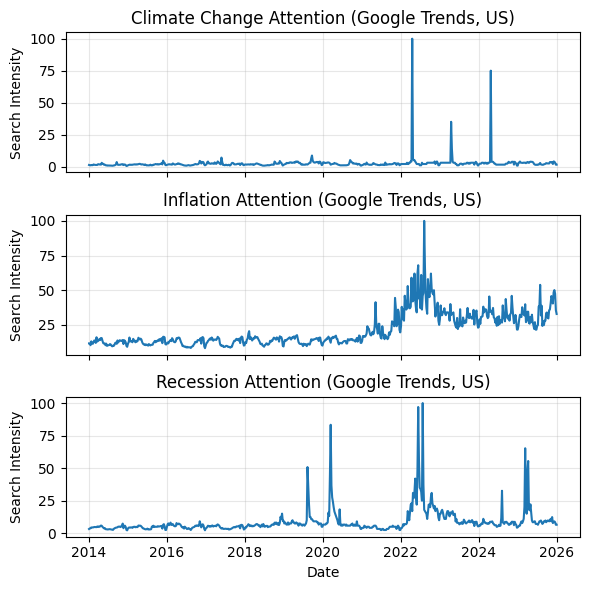

In [6]:
files = [
    ("data/google_climate_change_2014_2025.csv", "Climate Change"),
    ("data/google_inflation_2014_2025.csv", "Inflation"),
    ("data/google_recession_2014_2025.csv", "Recession"),
]

y = "index_0_100"

fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

for ax, (path, title) in zip(axes, files):
    df = pd.read_csv(path, parse_dates=["date"])
    ax.plot(df["date"], df[y])
    ax.set_title(f"{title} Attention (Google Trends, US)")
    ax.set_ylabel("Search Intensity")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()
